In [282]:
import numpy as np
import pandas as pd

In [312]:
#the data is to small. Laplacian may not suit?

In [313]:
#train

In [284]:
posting=['my dog has flea problems help please'.split(' '),'maybe not take him to dog park stupid'.split(' '),\
        'my dalmation is so cute I love him'.split(' '),'stop posting stupid worthless garbage'.split(' '),\
        'mr licks ate my steeak how to stop him'.split(' '),'quit buying worthless dog food stupid'.split(' ')]

classification=[0,1,0,1,0,1] #1 refers to bad comment

In [285]:
def creat_vocabuList(textList):
    vocabuList=set()
    for i in textList:
        vocabuList=vocabuList|set(i)
    return list(vocabuList)

In [286]:
def creat_victorFrame(textList,vocabuList,classification):
    textList_len=len(textList)
    vocaluList_len=len(vocabuList)
    
    victor=np.zeros((textList_len,vocaluList_len))
    vocabu_andclass=vocabuList.copy()
    vocabu_andclass.append('classification')  #Must.Or the vocabuList will be changed.Although it is not return and not in the function.
    
    row=len(classification)
    array_class=np.array(classification).reshape(row,1)
    
    for centence in range(textList_len):
        for word in textList[centence]:
            if word in vocabuList:
                victor[centence,vocabuList.index(word)]=1    ##list.index
            else:
                print(f'The word "{word}" is not in my vocabulary list')
    victor=np.concatenate([victor,array_class],axis=1)  #2d
    victorFrame=pd.DataFrame(victor,columns=vocabu_andclass)    
    return victorFrame
    

In [287]:
vocabuList=creat_vocabuList(posting)
victorFrame=creat_victorFrame(posting,vocabuList,classification)

victorFrame.iloc[-5:,-5:]

,my,ate,cute,dog,classification
1,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,1.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,1.0,1.0


In [288]:
def calculate_p(x):
    L_mother=len(np.unique(x))
    return (x.sum()+1)/(x.count()+L_mother)

In [289]:
def generate_classifier(frame):
    y_name=frame.columns[-1]
    y=frame[y_name]
    D=len(y)+len(y.value_counts())
    D_0=y[0]+1
    D_1=y[1]+1
    
    
    groupby_class=frame.groupby(y_name)
    p_feature=groupby_class.agg(calculate_p)
    p_0=D_0/D
    p_1=D_1/D

    #p_feature=p_feature/p_feature.values.sum(axis=1).reshape(2,1)  #just normalized and wait to ln. Don't need to normalize?

    return p_feature,p_0,p_1

In [290]:
p_feature,p_0,p_1=generate_classifier(victorFrame)

In [291]:
print(p_feature.iloc[:,-5:])  #p_feature means the posibility of 1 for every word in each class
print(f'p_0:{p_0}, p_1:{p_1}')

                stop    my   ate  cute  dog
classification                             
0.0              0.4  1.00  0.40  0.40  0.4
1.0              0.4  0.25  0.25  0.25  0.6
p_0:0.125, p_1:0.25


In [292]:
import matplotlib.pyplot as plt
%matplotlib inline

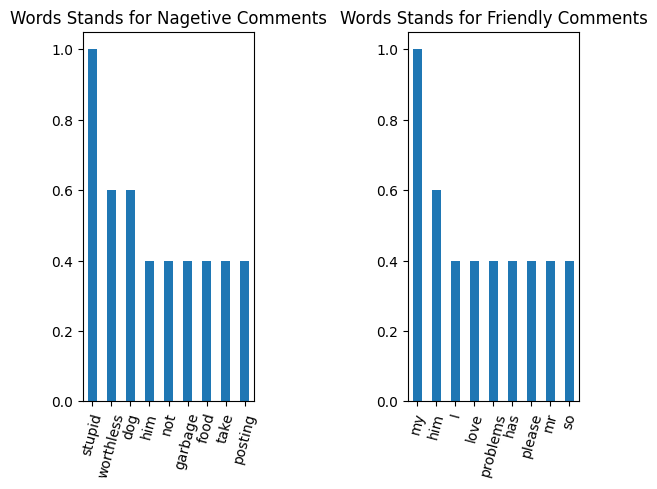

In [293]:
fig,axes=plt.subplots(1,2)
p_feature.sort_values(axis=1,by=1,ascending=False).iloc[1,:9].plot.bar(ax=axes[0],title='Words Stands for Nagetive Comments',rot=75)
p_feature.sort_values(axis=1,by=0,ascending=False).iloc[0,:9].plot.bar(ax=axes[1],title='Words Stands for Friendly Comments',rot=75)
fig.subplots_adjust(wspace=0.9)

In [310]:
#test

In [303]:
def calculate(row,p_feature,p_0,p_1):
        
   
    #feature_0=p_feature.loc[0]
    #feature_1=p_feature.loc[1]
        #feature_0.loc[feature==0.0]=1-feature_1.loc[feature==0.0]  ##It is difficult to write and easy to wrong
    #result_0=np.where(feature==1,feature_0,1-feature_0)
    #result_1=np.where(feature==1,feature_1,1-feature_1)
    
    #It's troubling. We can use np.tile(array/Series,(x,y)). Both Array and Series  will return an array.

    posibility=np.where(np.tile(row,(2,1))==1,p_feature,1-p_feature) #return an array row0 is p_0
    
    p_01=np.array([[p_0],[p_1]])
    result=np.concatenate([posibility,p_01],axis=1)

    L_result=np.log(result+1e-12).sum(axis=1)  #in case of x/0
    
    return np.argmax(L_result),1/(1+np.exp(L_result.min()-L_result.max()))
    
    

In [304]:
pre_test=[['love my dalmation'],['stupid garbage'],['I love my stupid dog']]

In [305]:
testList=['love my dalmation'.split(' '),'stupid garbage'.split(' '),'I love my stupid dog'.split(' ')] #infact this is the result after dealt

In [306]:
pre_class=np.zeros(len(testList))  #I don't want to change the function creat_victorFrame
victorTest=creat_victorFrame(testList,vocabuList,pre_class).iloc[:,:-1]

In [307]:
victorTest.iloc[:,-5:]

,stop,my,ate,cute,dog
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0


In [308]:
prediction=victorTest.apply(calculate,args=(p_feature,p_0,p_1,),axis=1,result_type='expand')
prediction.columns=['prediction','reliability']
prediction

,prediction,reliability
0,0.0,1.000000
1,1.0,1.000000
2,1.0,0.741001


In [309]:
#pd.concat([pd.DataFrame(inputTest,columns=['comments']),pd.DataFrame(prediction.values[:,np.newaxis],columns=['prediction'])],axis=1)
result=pd.concat([pd.DataFrame(pre_test,columns=['comments']),prediction],axis=1)
result

,comments,prediction,reliability
0,love my dalmation,0.0,1.000000
1,stupid garbage,1.0,1.000000
2,I love my stupid dog,1.0,0.741001
